## Can We Predict Public Transport Delays Before They Happen?

Can we predict whether a public transport journey will be delayed using information available before or around its scheduled departure?

What factors are most responsible for public transport delays?

Question 1
Can we predict whether a journey will be delayed?

Question 2
What factors contribute most to delays?

In [177]:
# Step 0 - Import libraries
# --------------------------

# Import the libraries needed for this section
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler,StandardScaler

from scipy.stats import chi2_contingency
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# For evaluating Regression models (Part 1)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# For evaluating Classification models (Part 2)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For Decision Trees
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# For Random Forest
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# For XGBoost
from xgboost import XGBRegressor, XGBClassifier

# Standard seed used throughout the notebook, for reproducibility
SEED = 1

In [178]:
# Load the dataset directly from GitHub
# This allows the notebook to be run without relying on a local file path.

url = "https://raw.githubusercontent.com/winifredpaul/public-transport-delay-prediction/main/data/public_transport_delays.csv"

transport_delay_df = pd.read_csv(url)

transport_delay_df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


## Initial Data Inspection

Before preparing the data for modelling, we inspect its structure, data types, numerical ranges and the presence of missing values.

This helps us understand the dataset and identify any issues that need to be addressed before building a machine learning model.

In [179]:
transport_delay_df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


In [180]:
transport_delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

## Data Preparation and Feature Selection

Not every column in the original dataset is suitable for use as a machine learning feature.

We remove identifier and station-related columns that are not being used in our current prediction approach:

- `trip_id` – a unique identifier for each journey.
- `date` – not currently being used as a predictive feature.
- `time` – not currently being used as a predictive feature.
- `origin_station` – excluded from the current model.
- `destination_station` – excluded from the current model.

We retain variables that may contain useful information about the conditions surrounding each journey.

The actual delay columns are retained temporarily for exploratory analysis, but will not be used as model features because they contain information about the outcome and could cause data leakage.

In [181]:
transport_delay_df = transport_delay_df.drop(
    columns=[
        "date",
        "time",
        "trip_id",
        "origin_station",
        "destination_station"
    ]
)

In [182]:
transport_delay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   transport_type              2000 non-null   object 
 1   route_id                    2000 non-null   object 
 2   scheduled_departure         2000 non-null   object 
 3   scheduled_arrival           2000 non-null   object 
 4   actual_departure_delay_min  2000 non-null   int64  
 5   actual_arrival_delay_min    2000 non-null   int64  
 6   weather_condition           2000 non-null   object 
 7   temperature_C               2000 non-null   float64
 8   humidity_percent            2000 non-null   int64  
 9   wind_speed_kmh              2000 non-null   int64  
 10  precipitation_mm            2000 non-null   float64
 11  event_type                  827 non-null    object 
 12  event_attendance_est        2000 non-null   int64  
 13  traffic_congestion_index    2000 

## Feature Engineering: Scheduled Times

The scheduled departure and arrival times are originally stored as time values. To make these variables suitable for machine learning models, we convert them into numerical values representing the number of minutes after midnight.

We retain the original time information in the dataset while creating numerical features for modelling.

In [183]:
# Convert scheduled times into datetime format so that we can extract the hour and minute components.
transport_delay_df["scheduled_departure"] = pd.to_datetime(
    transport_delay_df["scheduled_departure"],
    format="%H:%M:%S"
)

transport_delay_df["scheduled_arrival"] = pd.to_datetime(
    transport_delay_df["scheduled_arrival"],
    format="%H:%M:%S"
)

# Convert scheduled times into minutes after midnight.This creates numerical features that can be used by ML models.

transport_delay_df["departure_minutes"] = (
    transport_delay_df["scheduled_departure"].dt.hour * 60
    + transport_delay_df["scheduled_departure"].dt.minute
)

transport_delay_df["arrival_minutes"] = (
    transport_delay_df["scheduled_arrival"].dt.hour * 60
    + transport_delay_df["scheduled_arrival"].dt.minute
)

In [184]:
transport_delay_df[
    [
        "scheduled_departure",
        "departure_minutes",
        "scheduled_arrival",
        "arrival_minutes"
    ]
].head()

,scheduled_departure,departure_minutes,scheduled_arrival,arrival_minutes
0,1900-01-01 05:02:00,302,1900-01-01 05:55:00,355
1,1900-01-01 05:16:00,316,1900-01-01 05:55:00,355
2,1900-01-01 05:33:00,333,1900-01-01 06:17:00,377
3,1900-01-01 05:49:00,349,1900-01-01 06:08:00,368
4,1900-01-01 06:00:00,360,1900-01-01 06:35:00,395


## Inspecting the Target

In [185]:
delayed_trips = transport_delay_df[transport_delay_df["delayed"] == 0]

delayed_trips.tail()

,transport_type,route_id,scheduled_departure,scheduled_arrival,actual_departure_delay_min,actual_arrival_delay_min,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,...,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed,departure_minutes,arrival_minutes
1973,Metro,Route_17,1900-01-01 18:17:00,1900-01-01 18:44:00,6,0,Cloudy,2.7,78,29,...,Sports,500,87,0,0,5,Autumn,0,1097,1124
1977,Tram,Route_8,1900-01-01 19:16:00,1900-01-01 19:53:00,-2,-1,Cloudy,14.5,84,16,...,NaN,0,64,0,0,5,Autumn,0,1156,1193
1984,Train,Route_20,1900-01-01 21:00:00,1900-01-01 21:35:00,6,-3,Rain,4.0,86,18,...,NaN,0,43,0,1,5,Autumn,0,1260,1295
1985,Train,Route_15,1900-01-01 21:18:00,1900-01-01 21:40:00,17,2,Cloudy,6.1,87,38,...,NaN,0,71,0,0,5,Summer,0,1278,1300
1993,Bus,Route_18,1900-01-01 23:15:00,1900-01-01 23:51:00,6,0,Cloudy,32.1,78,1,...,NaN,500,53,0,1,5,Summer,0,1395,1431


In [186]:
transport_delay_df.groupby("delayed")["actual_arrival_delay_min"].describe()

,count,mean,std,min,25%,50%,75%,max
delayed,,,,,,,,
0,501.0,1.049900,2.617538,-3.0,-1.0,1.0,3.0,5.0
1,1499.0,17.418279,6.761271,6.0,11.0,17.0,23.0,29.0


In [187]:
pd.crosstab(
    transport_delay_df["delayed"],
   transport_delay_df["actual_arrival_delay_min"] > 0
)

actual_arrival_delay_min,False,True
delayed,,
0,220,281
1,0,1499


In [188]:
transport_delay_df[transport_delay_df["delayed"] == 0]["actual_arrival_delay_min"].value_counts()

actual_arrival_delay_min
 4    62
-2    61
 5    57
 2    57
 3    55
 0    55
-3    55
 1    50
-1    49
Name: count, dtype: int64

### Finding: Definition of a Delay

The analysis shows that the target variable `delayed` is strongly related to `actual_arrival_delay_min`.

In this dataset:

- `delayed = 0` corresponds to an actual arrival delay of between -3 and 5 minutes.
- `delayed = 1` corresponds to an actual arrival delay of between 6 and 29 minutes.

The dataset appears to classify a journey as delayed when the actual arrival delay is **6 minutes or more**.

This distinction is important because a small positive arrival delay does not necessarily mean that the journey is classified as delayed.

## Selecting Features

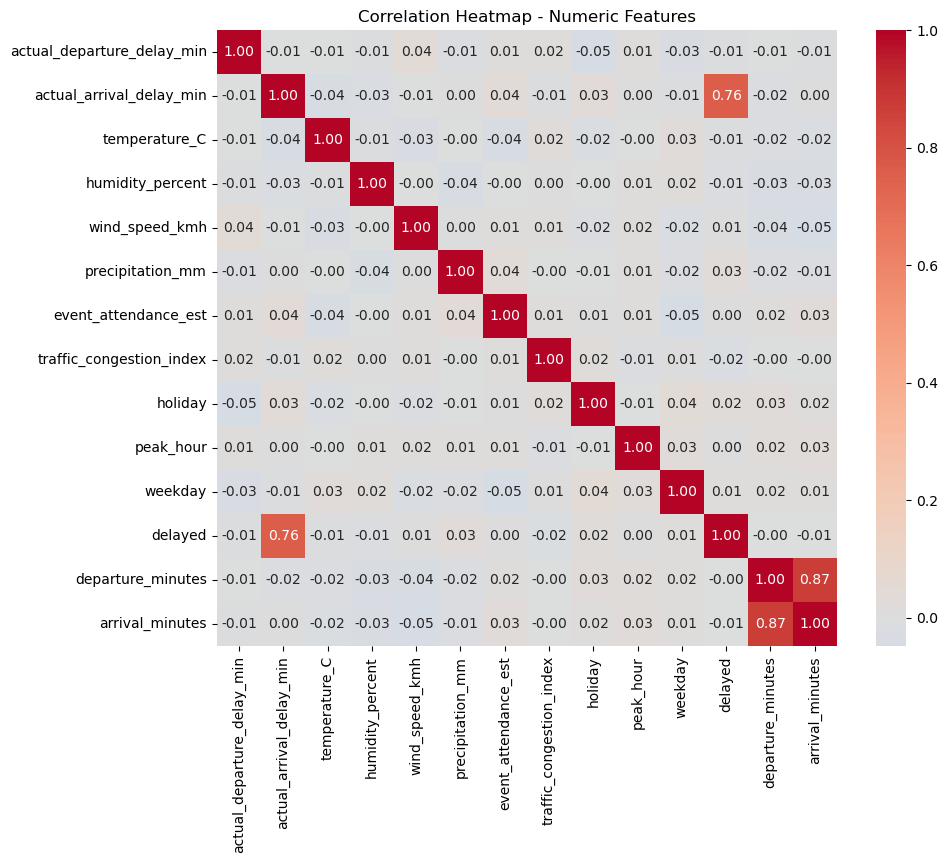

In [189]:
# Select numeric columns only
numeric_df = transport_delay_df.select_dtypes(include="number")

# Calculate correlations
full_corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    full_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap - Numeric Features")
plt.show()

## Selecting Features and Target

We now separate the dataset into the predictor variables (`X`) and the target variable (`y`).

The target variable is `delayed`, which indicates whether the journey is classified as delayed.

The selected features represent information that could potentially be available before or around the scheduled journey, including transport type, route, scheduled timing, weather, traffic, calendar information and events.

The actual departure and arrival delay variables are excluded because they describe what happened during the journey. Including them as predictors would introduce data leakage.

In [190]:
# Select the features (X) and the target (y)
X = transport_delay_df[
    [
        "transport_type",
        "route_id",
        "departure_minutes",
        "arrival_minutes",
        "weather_condition",
        "temperature_C",
        "humidity_percent",
        "wind_speed_kmh",
        "precipitation_mm",
        "traffic_congestion_index",
        "holiday",
        "peak_hour",
        "weekday",
        "season",
        "event_type",
        "event_attendance_est"
    ]
]

y = transport_delay_df["delayed"]
X.describe()

,departure_minutes,arrival_minutes,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,traffic_congestion_index,holiday,peak_hour,weekday,event_attendance_est
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,718.785000,723.38850,15.121350,64.714000,29.300500,9.860700,50.244000,0.089500,0.272000,2.976000,6420.250000
std,414.536045,415.02517,11.479424,20.334747,17.264015,5.781373,29.225751,0.285535,0.445101,1.990328,15198.306129
min,0.000000,0.00000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,362.750000,368.00000,5.100000,46.000000,15.000000,4.900000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,721.000000,725.50000,15.300000,65.000000,29.000000,9.700000,50.000000,0.000000,0.000000,3.000000,0.000000
75%,1081.000000,1082.25000,24.800000,83.000000,45.000000,14.800000,76.000000,0.000000,1.000000,5.000000,2000.000000
max,1429.000000,1439.00000,35.000000,99.000000,59.000000,20.000000,99.000000,1.000000,1.000000,6.000000,50000.000000


## Handling Missing Values in Event Type

The `event_type` column contains missing values. Instead of removing these rows, we treat the missing values as a separate category called `Unknown`.

This allows us to keep all available journeys in the dataset while allowing the One-Hot Encoder to process the missing information as a categorical value.

In [191]:
# Replace missing event types with "Unknown"
X = X.copy()
X["event_type"] = X["event_type"].fillna("Unknown")

In [192]:
X["event_type"].value_counts()

event_type
Unknown     1173
Festival     221
Sports       212
Concert      203
Parade       105
Protest       86
Name: count, dtype: int64

In [193]:
categorical_columns = [
    "transport_type",
    "route_id",
    "weather_condition",
    "season",
    "event_type"
]

In [194]:
for col in categorical_columns:
    print(f"\n{col}:")
    print(X[col].unique())


transport_type:
['Tram' 'Metro' 'Bus' 'Train']

route_id:
['Route_15' 'Route_12' 'Route_16' 'Route_19' 'Route_8' 'Route_17'
 'Route_5' 'Route_6' 'Route_18' 'Route_9' 'Route_13' 'Route_10' 'Route_7'
 'Route_14' 'Route_20' 'Route_3' 'Route_2' 'Route_11' 'Route_4' 'Route_1']

weather_condition:
['Storm' 'Rain' 'Clear' 'Snow' 'Fog' 'Cloudy']

season:
['Winter' 'Autumn' 'Spring' 'Summer']

event_type:
['Unknown' 'Sports' 'Protest' 'Parade' 'Concert' 'Festival']


In [195]:
# Step 2: Train / Test Split
# ---------------------------
# Split the data into training and testing sets. Stratification preserves the proportion of delayed and non-delayed journeys in both datasets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (1600, 16)
X_test shape:  (400, 16)


In [196]:
# Select the numerical features
numerical_columns = [
    "departure_minutes",
    "arrival_minutes",
    "temperature_C",
    "humidity_percent",
    "wind_speed_kmh",
    "precipitation_mm",
    "traffic_congestion_index",
    "holiday",
    "peak_hour",
    "weekday",
    "event_attendance_est"
]

X_train_numerical_df = X_train[numerical_columns].copy()
X_test_numerical_df = X_test[numerical_columns].copy()

In [197]:
# One-Hot Encoding on categorical features
# ------------------------------------------

# 1. Create the encoder
encoder = OneHotEncoder(
    sparse_output=False,
    drop="first",
    handle_unknown="ignore"
)

# 2. Fit and transform on training data
X_train_encoded = encoder.fit_transform(
    X_train[categorical_columns]
)

# Transform test data using the same encoder
X_test_encoded = encoder.transform(
    X_test[categorical_columns]
)

# 3. Get the resulting column names
encoded_cols = encoder.get_feature_names_out(
    categorical_columns
)

# 4. Create readable DataFrames
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_cols,
    index=X_train.index
)

X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_cols,
    index=X_test.index
)

X_train_encoded_df.head()

,transport_type_Metro,transport_type_Train,transport_type_Tram,route_id_Route_10,route_id_Route_11,route_id_Route_12,route_id_Route_13,route_id_Route_14,route_id_Route_15,route_id_Route_16,...,weather_condition_Snow,weather_condition_Storm,season_Spring,season_Summer,season_Winter,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown
1854,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1583,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
753,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
129,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1969,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [198]:
# Combine encoded categorical features with numerical features

X_train_final = pd.concat(
    [X_train_numerical_df, X_train_encoded_df],
    axis=1
)

X_test_final = pd.concat(
    [X_test_numerical_df, X_test_encoded_df],
    axis=1
)

In [199]:
X_train_final.head()

,departure_minutes,arrival_minutes,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,traffic_congestion_index,holiday,peak_hour,weekday,...,weather_condition_Snow,weather_condition_Storm,season_Spring,season_Summer,season_Winter,event_type_Festival,event_type_Parade,event_type_Protest,event_type_Sports,event_type_Unknown
1854,752,792,30.4,61,34,16.7,92,0,0,4,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1583,1006,1053,-1.7,68,22,1.9,52,0,0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
753,78,96,-4.0,37,15,15.4,93,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
129,799,850,22.8,43,13,10.0,73,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1969,1036,1088,-4.5,59,23,7.7,23,0,0,5,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [200]:
X_train_final.shape

(1600, 46)

## Checking for Missing Values

After handling the missing values in `event_type`, we check the remaining numerical features for missing values.

The numerical features contain no missing values, so no additional imputation is required at this stage.

In [201]:
# Check the final training and testing datasets for missing values

print("Missing values in X_train_final:")
print(X_train_final.isnull().sum().sum())

print("\nMissing values in X_test_final:")
print(X_test_final.isnull().sum().sum())

Missing values in X_train_final:
0

Missing values in X_test_final:
0


## Checking the Final Dataset

After handling missing values and completing the feature encoding, we check the final training and testing datasets for any remaining missing values.

Both datasets contain no missing values, so they are ready for modelling.

# UPDATE

# Public Transport Delay Prediction — Key Project Notes

## Data Preparation

- Dataset is stored on GitHub so the notebook can access it without relying on a local file.

- Target variable:
  - `delayed = 0` → Not delayed
  - `delayed = 1` → Delayed

- Removed unnecessary/identifier columns:
  - `trip_id`
  - `date`
  - `time`
  - `origin_station`
  - `destination_station`

- Removed `actual_departure_delay_min` and `actual_arrival_delay_min` from `X` to avoid **data leakage**, as these values are only known after the journey.

## Feature Engineering

- Converted:
  - `scheduled_departure` → `departure_minutes`
  - `scheduled_arrival` → `arrival_minutes`

- We decided **not** to create separate `departure_hour` / `arrival_hour` features.

- Added `event_type` as a potential predictor because events may influence passenger numbers and transport delays.

- Missing `event_type` values were replaced with `Unknown` rather than removing those rows.

